LOAD DATA

In [1]:
import pandas as pd

# load data
url_skj = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/Coba2/2.%20SKJ%20JF%20Perluasan.csv"
url_pelatihan = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/Coba2/3.%20Katalog%20Pelatihan%202018-2024%20(Puspa).csv"

skj = pd.read_csv(url_skj)
pelatihan = pd.read_csv(url_pelatihan, sep=';')

In [2]:
pelatihan = pelatihan.reset_index(drop=True)

pelatihan['id_pelatihan'] = pelatihan.index.map(lambda x: f"PEL-{x+1:04d}")

In [3]:
skj = skj.reset_index(drop=True)

skj['id_skj'] = skj.index.map(lambda x: f"SKJ-{x+1:04d}")

In [4]:
display(skj.head())

,nama_skj,id_skj
0,Advokasi Kebijakan Perpajakan,SKJ-0001
1,Analisis Data,SKJ-0002
2,Analisis Hasil Pengawasan,SKJ-0003
3,Analisis Hukum Internasional,SKJ-0004
4,Analisis Kebijakan Publik di Bidang Keuangan N...,SKJ-0005


In [5]:
display(pelatihan.head())

,nama_pelatihan,penyelenggara,tahun,id_pelatihan
0,Diklat Fungsional Pemeriksa Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0001
1,Diklat Teknis Substantif Spesialisasi Pemeriks...,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0002
2,DTS Perpajakan Menengah,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0003
3,DTSS Account Representative Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0004
4,DTSS Analis IDLP Dasar,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0005


In [6]:
print("Kolom Pelatihan:", pelatihan.columns)
print("Kolom SKJ:", skj.columns)

Kolom Pelatihan: Index(['nama_pelatihan', 'penyelenggara', 'tahun', 'id_pelatihan'], dtype='object')
Kolom SKJ: Index(['nama_skj', 'id_skj'], dtype='object')


In [7]:
col_pelatihan = 'nama_pelatihan'
col_skj = 'nama_skj'

DATA PREPARATION

In [8]:
import re

stop_words_katalog = {
        'pelatihan', 'jarak', 'jauh', 'e-learning', 'elearning', 'diklat', 'df',
        'dtsd', 'dts', 'dtss', 'training', 'excecutive', 'training', 'sharing', 'session', 'fgd',
        'focus', 'group', 'discussion', 'in', 'house', 'kemenkeu', 'corporate',
        'university', 'corpu', 'open', 'class', 'lokakarya', 'microlearning',
        'blended', 'pjj', 'seminar', 'workshop', 'uji', 'kompetensi', 'teknis',
        'of', 'trainers', 'dan', 'di', 'ke', 'dari', 'untuk', 'pada', 'dalam',
        'yang', 'level', 'tingkat', 'nasional', 'angkatan',
        'tahun', 'batch', 'program', 'studi', 'bimtek', 'sosialisasi'
    }

def clean_text(text):
    text = str(text).lower()

    # 🔥 hapus pola "batch 2", "angkatan 3", dll
    text = re.sub(r'\b(batch|angkatan|tahun)\s*\d+\b', '', text)

    # hapus simbol & angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in stop_words_katalog]

    return ' '.join(words)

In [9]:
pelatihan['clean'] = pelatihan['nama_pelatihan'].apply(clean_text)
skj['clean'] = skj['nama_skj'].apply(clean_text)

In [10]:
pelatihan[['nama_pelatihan','clean']].head(10)

,nama_pelatihan,clean
0,Diklat Fungsional Pemeriksa Dasar,fungsional pemeriksa dasar
1,Diklat Teknis Substantif Spesialisasi Pemeriks...,substantif spesialisasi pemeriksa pajak daerah
2,DTS Perpajakan Menengah,perpajakan menengah
3,DTSS Account Representative Dasar,account representative dasar
4,DTSS Analis IDLP Dasar,analis idlp dasar
5,DTSS Forensik Digital Perpajakan,forensik digital perpajakan
6,DTSS Forensik Digital Perpajakan Menengah,forensik digital perpajakan menengah
7,DTSS Juru Sita Pajak,juru sita pajak
8,DTSS Juru Sita Pajak Lanjutan,juru sita pajak lanjutan
9,DTSS Jurusita Pajak Daerah Kerja Sama Program ...,jurusita pajak daerah kerja sama pusdiklat paj...


In [11]:
skj[['nama_skj','clean']].head()

,nama_skj,clean
0,Advokasi Kebijakan Perpajakan,advokasi kebijakan perpajakan
1,Analisis Data,analisis data
2,Analisis Hasil Pengawasan,analisis hasil pengawasan
3,Analisis Hukum Internasional,analisis hukum internasional
4,Analisis Kebijakan Publik di Bidang Keuangan N...,analisis kebijakan publik bidang keuangan negara


MODELING

In [12]:
!pip install transformers torch

In [13]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [14]:
labels = skj['nama_skj'].tolist()

In [15]:
def map_zero_shot(text, labels):
    result = classifier(
        text,
        candidate_labels=labels,
        multi_label=True
    )

    labels_sorted = result['labels']
    scores_sorted = result['scores']

    # 🔥 RULE LOGIC
    if scores_sorted[0] >= 0.6:
        n = 1
    elif scores_sorted[0] >= 0.4:
        n = 2
    else:
        n = 3

    output = []

    for i in range(n):
        output.append({
            'kompetensi': labels_sorted[i],
            'skor': scores_sorted[i]
        })

    return output

In [16]:
sample_data = pelatihan.sample(5).reset_index(drop=True)
sample_data

,nama_pelatihan,penyelenggara,tahun,id_pelatihan,clean
0,E-Learning Proses Bisnis Penilaian,Pusat Pendidikan dan Pelatihan Pajak,2022,PEL-0131,e learning proses bisnis penilaian
1,Open Class Seri V Pemulihan Ekonomi Nasional (...,Pusat Pendidikan dan Pelatihan Pajak,2020,PEL-0206,seri v pemulihan ekonomi pen insentif pajak ma...
2,Pelatihan Teknis Perpajakan untuk Pegawai non DJP,Pusat Pendidikan dan Pelatihan Pajak,2018,PEL-0445,perpajakan pegawai non djp
3,Pelatihan Jarak Jauh Pemeriksaan Bukti Permula...,Pusat Pendidikan dan Pelatihan Pajak,2022,PEL-0305,pemeriksaan bukti permulaan i
4,Seminar Digital Kemenkeu Corporate University ...,Pusat Pendidikan dan Pelatihan Pajak,2020,PEL-0477,digital talk bea meterai era digital apa bagai...


In [17]:
sample_data['nama_pelatihan']

,nama_pelatihan
0,E-Learning Proses Bisnis Penilaian
1,Open Class Seri V Pemulihan Ekonomi Nasional (...
2,Pelatihan Teknis Perpajakan untuk Pegawai non DJP
3,Pelatihan Jarak Jauh Pemeriksaan Bukti Permula...
4,Seminar Digital Kemenkeu Corporate University ...


In [18]:
results = []

for i in range(len(sample_data)):
    text = sample_data.loc[i, 'nama_pelatihan']

    mapped = map_zero_shot(text, labels)

    for rank, item in enumerate(mapped):
        results.append({
            'nama_pelatihan': text,
            'rank': rank + 1,
            'kompetensi': item['kompetensi'],
            'skor': item['skor']
        })

sample_mapping = pd.DataFrame(results)
sample_mapping

,nama_pelatihan,rank,kompetensi,skor
0,E-Learning Proses Bisnis Penilaian,1,Penanganan Perkara,0.944911
1,Open Class Seri V Pemulihan Ekonomi Nasional (...,1,Penyidikan Perpajakan,0.991931
2,Pelatihan Teknis Perpajakan untuk Pegawai non DJP,1,Penatausahaan Penagihan Pajak,0.833996
3,Pelatihan Jarak Jauh Pemeriksaan Bukti Permula...,1,Dukungan Kegiatan Investigasi,0.984314
4,Seminar Digital Kemenkeu Corporate University ...,1,Pengelolaan Hubungan Dengan Pemangku Kepenting...,0.975090


In [19]:
from tqdm import tqdm

results = []

for i in tqdm(range(len(pelatihan))):
    text = pelatihan.loc[i, 'nama_pelatihan']

    mapped = map_zero_shot(text, labels)

    for rank, item in enumerate(mapped):
        results.append({
            'id_pelatihan': pelatihan.loc[i, 'id_pelatihan'],
            'nama_pelatihan': text,
            'rank': rank + 1,
            'kompetensi': item['kompetensi'],
            'skor': item['skor']
        })

100%|██████████| 509/509 [04:54<00:00,  1.73it/s]


In [20]:
import pandas as pd

mapping_zs = pd.DataFrame(results)
mapping_zs.head()

,id_pelatihan,nama_pelatihan,rank,kompetensi,skor
0,PEL-0001,Diklat Fungsional Pemeriksa Dasar,1,Intelijen Perpajakan,0.908483
1,PEL-0002,Diklat Teknis Substantif Spesialisasi Pemeriks...,1,Penyidikan Perpajakan,0.992466
2,PEL-0003,DTS Perpajakan Menengah,1,Analisis Kebijakan Publik di Bidang Keuangan N...,0.967342
3,PEL-0004,DTSS Account Representative Dasar,1,Pengelolaan Hubungan Dengan Pemangku Kepenting...,0.946229
4,PEL-0005,DTSS Analis IDLP Dasar,1,Forensik Digital Perpajakan,0.956729


In [21]:
final_output = mapping_zs.groupby(
    ['id_pelatihan','nama_pelatihan']
).agg({
    'kompetensi': list,
    'skor': list
}).reset_index()

In [22]:
# final mapping
final_output.to_excel('mapping_final.xlsx', index=False)

# download
from google.colab import files
files.download('mapping_final.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EVALUASI

In [23]:
url_manual = "https://raw.githubusercontent.com/danangtric/PJJ_Data_Analytics_2026/refs/heads/main/4.%20Data%20training%20(pemetaan%20manual).csv"

manual = pd.read_csv(url_manual, sep=";")
manual.head()

,nama_pelatihan,kompetensi_1,kompetensi_2,kompetensi_3,kompetensi_4,kompetensi_5,kompetensi_6,kompetensi_7
0,E-Learning Analisis Laporan Keuangan dan Surat...,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Profiling Wajib Pajak,NaN,NaN,NaN
1,E-Learning Analisis Laporan Keuangan dan Surat...,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Profiling Wajib Pajak,NaN,NaN,NaN
2,E-Learning Pajak Dasar,Analisis Kepatuhan Wajib Pajak,Analisis Potensi Pajak,Analisis Profil Risiko Wajib Pajak,Penanganan Keberatan-Non Keberatan,Penanganan Perkara,Profiling Wajib Pajak,NaN
3,E-learning Penagihan Pajak Daerah (Open Access...,Pelaksanaan Tindakan Penagihan Pajak,Penatausahaan Penagihan Pajak,NaN,NaN,NaN,NaN,NaN
4,E-Learning Pengantar E-Audit Perpajakan,Pemeriksaan Pajak,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
import pandas as pd

# Data manual: gabungkan kolom kompetensi jadi list
kompetensi_cols = [f'kompetensi_{i}' for i in range(1,8)]
manual['kompetensi_manual'] = manual[kompetensi_cols].values.tolist()

# Prediksi mapping_zs: pastikan sudah punya list per pelatihan
pred_df = mapping_zs.groupby('nama_pelatihan')['kompetensi'].apply(list).reset_index()

# Gabungkan manual & prediksi
eval_df = pred_df.merge(
    manual[['nama_pelatihan','kompetensi_manual']],
    on='nama_pelatihan',
    how='inner'
)

In [25]:
# Hitung Jaccard Index
def jaccard(true, pred):
    set_true = set([k for k in true if pd.notna(k)])  # buang NaN
    set_pred = set([k for k in pred if pd.notna(k)])
    if not set_true and not set_pred:
        return 1
    return len(set_true & set_pred) / len(set_true | set_pred)

eval_df['jaccard'] = eval_df.apply(lambda x: jaccard(x['kompetensi_manual'], x['kompetensi']), axis=1)


Rata-rata Jaccard: 0.24281385281385282


<Axes: >

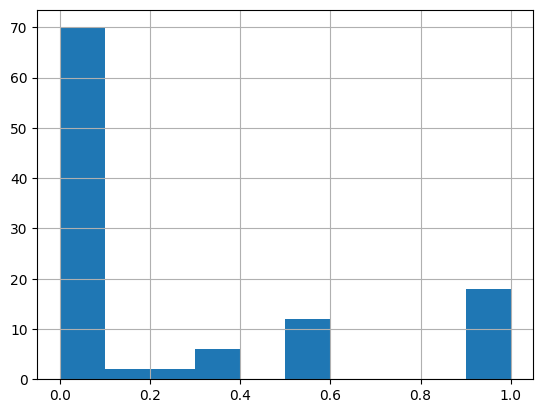

In [26]:
#Statistik evaluasi
print("Rata-rata Jaccard:", eval_df['jaccard'].mean())
eval_df['jaccard'].hist(bins=10)